In [70]:
import numpy as np
import matplotlib.pyplot as plt

In [71]:
from pathlib import Path

ROOT_DIR = Path(__doc__).resolve().parent.parent
location = ROOT_DIR / "data" / "field_lines" / "gs"

eta = 0.5
sn = 4  # sample number

fl_file = location / f"eta{eta:.1f}" / f"lines_eta{eta:.1f}_s{sn}.npz"

data = np.load(fl_file)

step = 20

s = data["s"][::step]
lines_from_zero = data["lines"][::step]
fields = data["fields"][::step]

L = 300  # [pc]
M = fields.shape[1]

## Observer view

Let observer direction be $\hat{n} = (\sin\phi, 0, \cos\phi)$.
In this case, we have to project the MF line onto the surface $\sigma: \vec{r}\cdot\hat{n} = 0.$

Projected vector is given by $\vec{r}_\sigma = \vec{r} - \hat{n}(\vec{r}\cdot\hat{n}) $

In [72]:
phi = np.linspace(0, 2 * np.pi, 36, endpoint=False)

n_vectors = np.array([np.sin(phi), np.zeros_like(phi), np.cos(phi)]).T
n_vectors.shape

(36, 3)

In [73]:
r_sigma = lines_from_zero[..., None, :]- n_vectors[None, None, ...] * np.sum(lines_from_zero[..., None, :] * n_vectors[None, None, ...], axis=-1, keepdims=True)

In [74]:
# create rotation matrix such that R n = z

In [75]:
ez = np.array([0, 0, 1]).T
a_nn = np.cross(n_vectors, ez)
a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # axis of rotation

theta = np.arccos(n_vectors @ ez)  # rotation angle

cross_a_r = np.cross(a, r_sigma)
dot_a_r = np.sum(a[None, None, ...] * r_sigma, axis=-1, keepdims=True)

/tmp/ipykernel_70129/2504275671.py:3: RuntimeWarning: invalid value encountered in divide
  a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # axis of rotation


In [76]:
rotated = r_sigma * np.cos(theta)[None, None, :, None] \
    + cross_a_r * np.sin(theta)[None, None, :, None] \
    + a[None, None, ...] * dot_a_r * (1 - np.cos(theta))[None, None, :, None]

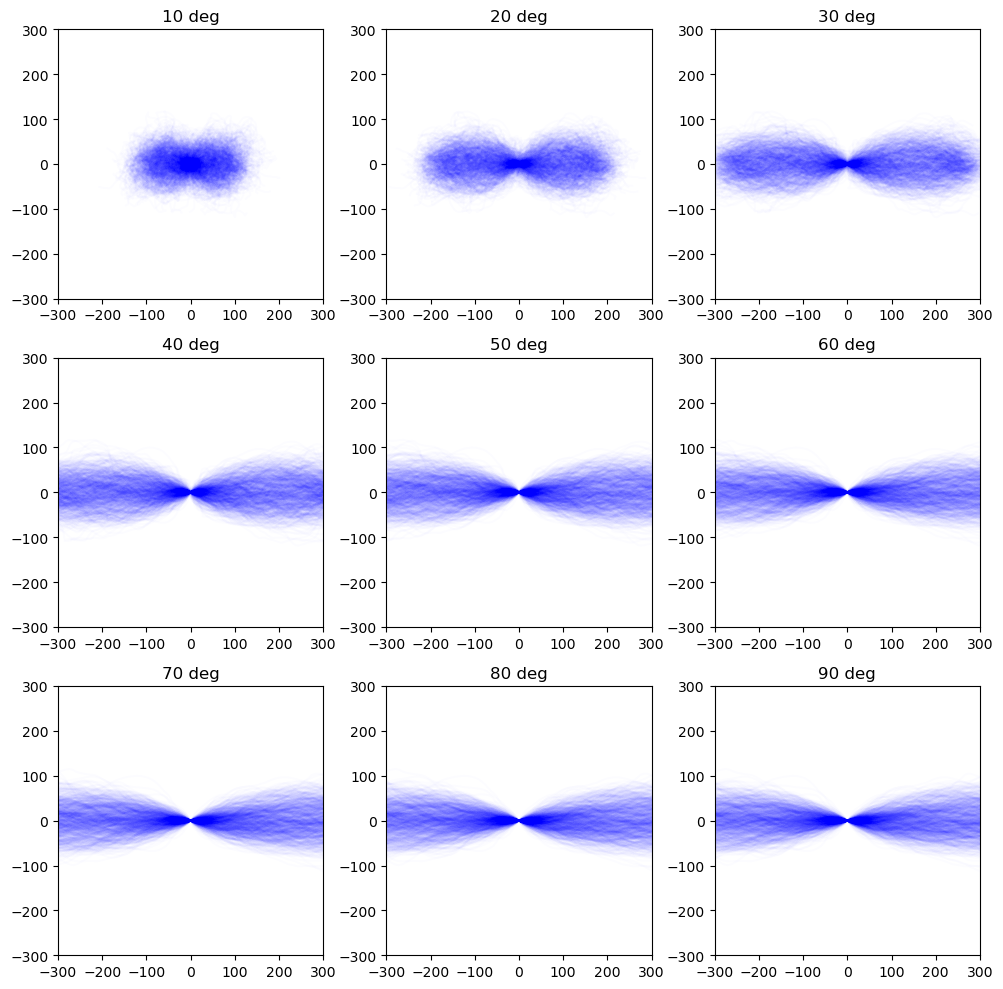

In [112]:
plt.figure(figsize=(10, 10))

for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.title(f"{np.rad2deg(phi[i]):.0f} deg")
    plt.xlim(-L, L)
    plt.ylim(-L, L)
    for m in range(0, M):
        x, y = rotated[:, m, i, 0], rotated[:, m, i, 1]
        plt.plot(x, y, color='blue', alpha=.01)

plt.tight_layout()
plt.show()

In [78]:
# Now we challenge the peanut geometry

In [79]:
import astropy.units as u
from astropy.coordinates import SkyCoord

peanut = SkyCoord(ra='02h15m6.50s', dec='+42d32m17.42', frame='icrs', distance=3 * u.kpc)
peanut_ang_length = 4.60 * u.deg
peanut_ang_width = 0.45 * u.deg
peanut_angle = 13.8 * u.deg  # to RA axis, almost aligned with b=cst

peanut_gal = peanut.galactic
peanut_length = np.abs(peanut_ang_length.to_value(u.rad) * peanut.distance * np.cos(peanut_gal.l)).to(u.pc)
peanut_width = (peanut_ang_width.to_value(u.rad) * peanut.distance).to(u.pc)
print(f"Peanut size is {peanut_length:.1f} x {peanut_width:.1f}")

Peanut size is 181.7 pc x 23.6 pc


In [99]:
from matplotlib.patches import Rectangle

# Finally, count the lines inside
x, y = rotated[..., 0], rotated[..., 1]

x_in = (x > 0) * (x < peanut_length.value)
y_in = (np.abs(y) < peanut_width.value / 2)
xy_in = np.bool_(x_in * y_in + ~x_in)
x_up = x > peanut_length.value  # peanut length

counter = np.sum(np.bool_(np.prod(xy_in, axis=0) * np.sum(x_up, axis=0)), axis=0)
print(counter[1:10])

[ 0  1 17 30 52 65 82 96 99]


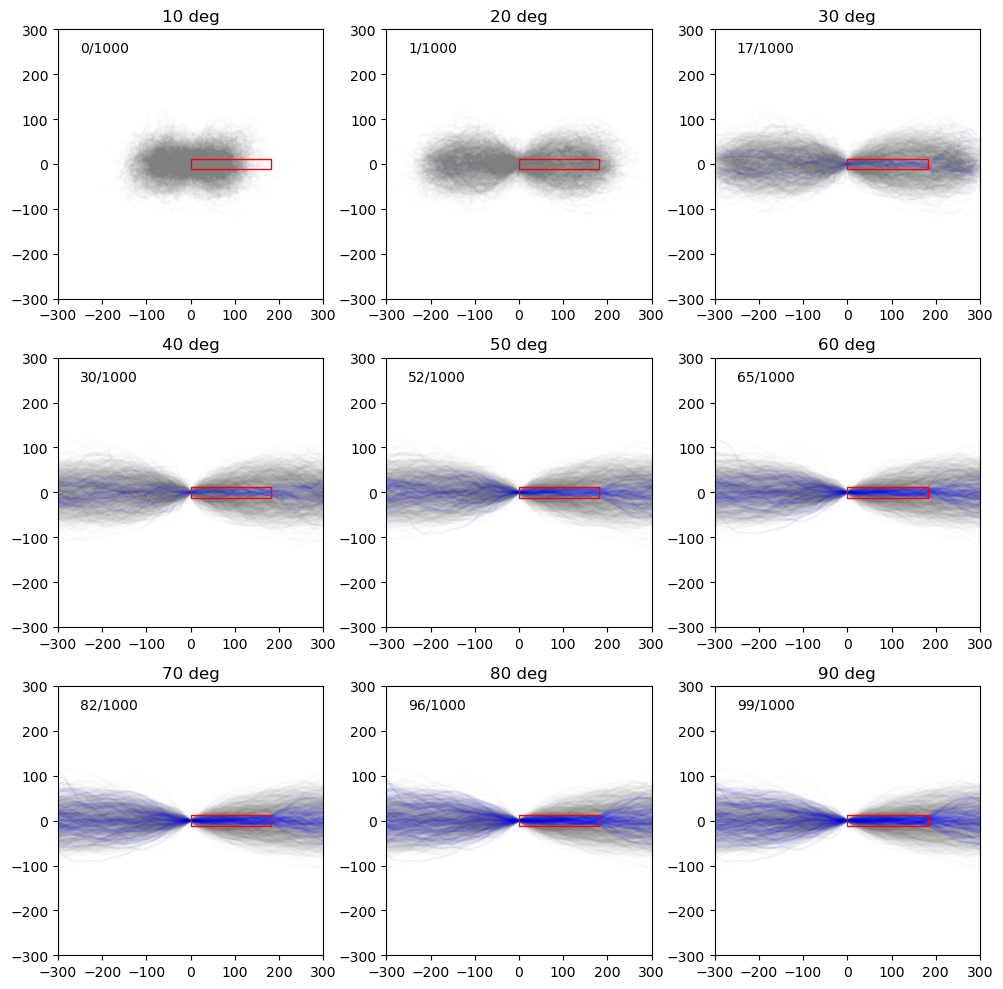

In [110]:
plt.figure(figsize=(10, 10))

# observer angle
for i in range(1, 10):
    ax = plt.subplot(3, 3, i)
    ax.set_title(f"{np.rad2deg(phi[i]):.0f} deg")
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    
    counter = 0
    
    for m in range(0, M):
        x, y = rotated[:, m, i, 0], rotated[:, m, i, 1]
        
        x_in = (x > 0) * (x < peanut_length.value)
        xy_in = np.abs(y[x_in]) < peanut_width.value / 2
        
        x_up = x > peanut_length.value  # peanut length
        
        color = 'gray'
        alpha = .02
        zorder = 0
        
        if np.prod(xy_in) > 0 and len(xy_in) > 0 and np.sum(x_up) > 0:
            color = 'blue'
            alpha = .05
            zorder = 9
            counter += 1
        
        ax.plot(x, y, color=color, alpha=alpha, zorder=zorder)
    
    rect = Rectangle((0, -peanut_width.value/2), width=peanut_length.value, height=peanut_width.value,
                     facecolor='none', edgecolor='red', linewidth=1, zorder=10)
    ax.add_patch(rect)
    ax.text(-250, 250, f"{counter}/{M}")

plt.tight_layout()
plt.show()